In [1]:
import os,sys
import math
import numpy as np
import pandas as pd
import dask.dataframe as dd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import confusion_matrix, cohen_kappa_score, roc_curve, auc
from datetime import timedelta



In [6]:
df1 = dd.read_parquet('/root/data/rrr/integrated_weather_dataset/data/integrated/parquet_fixed/2017.parquet')
df2 = dd.read_parquet('/root/data/rrr/ES3-TACLS/AR/dataset/parquet/2017.parquet')
pdf1 = df1.compute()
pdf2 = df2.compute()


In [7]:
pdf2

,Timestamp,Site,Latitude,Longitude,ZWD,Guan_AR_Label,Rutz_AR_Label
0,2017-01-01 00:00:00,7ODM,34.116407,-117.093192,86.7,0,0
1,2017-01-01 00:05:00,7ODM,34.116407,-117.093192,86.9,0,0
2,2017-01-01 00:10:00,7ODM,34.116407,-117.093192,87.0,0,0
3,2017-01-01 00:15:00,7ODM,34.116407,-117.093192,87.1,0,0
4,2017-01-01 00:20:00,7ODM,34.116407,-117.093192,87.3,0,0
...,...,...,...,...,...,...,...
49598861,2017-12-31 23:35:00,YUHG,32.647566,-115.922234,77.0,0,0
49598862,2017-12-31 23:40:00,YUHG,32.647566,-115.922234,77.1,0,0
49598863,2017-12-31 23:45:00,YUHG,32.647566,-115.922234,77.2,0,0
49598864,2017-12-31 23:50:00,YUHG,32.647566,-115.922234,77.2,0,0


In [8]:
pdf1['Timestamp'] = pd.to_datetime(pdf1['Timestamp'])
fi1 = pdf1[(pdf1['Site'] == 'ARM1') & 
                   (pdf1['Timestamp'] >= '2017-05-16') & 
                   (pdf1['Timestamp'] <= '2017-05-19')]

fi1

,Timestamp,Site,Latitude,Longitude,ZWD,Wet Gradient North,Wet Gradient East,IVT,Rutz_Label_exact,IVT_approx,Rutz_Label_approx,Guan_Label_exact,Guan_Label_approx,Precipitation_Label_exact,Precipitation_Label_approx,ffw
111735,2017-05-16 00:00:00.000002,ARM1,35.201252,-118.910421,94.2,-0.31,-0.12,NaN,NaN,106.299217,0.0,NaN,0.0,NaN,0.0,0
111736,2017-05-16 00:05:00.000002,ARM1,35.201252,-118.910421,94.3,-0.31,-0.12,NaN,NaN,106.299217,0.0,NaN,0.0,NaN,0.0,0
111739,2017-05-16 00:10:00.000002,ARM1,35.201252,-118.910421,94.4,-0.31,-0.13,NaN,NaN,106.299217,0.0,NaN,0.0,NaN,0.0,0
111740,2017-05-16 00:15:00.000002,ARM1,35.201252,-118.910421,94.6,-0.31,-0.12,NaN,NaN,106.299217,0.0,NaN,0.0,NaN,0.0,0
111743,2017-05-16 00:20:00.000002,ARM1,35.201252,-118.910421,94.9,-0.30,-0.10,NaN,NaN,106.299217,0.0,NaN,0.0,NaN,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659509,2017-05-18 23:39:59.999999,ARM1,35.201252,-118.910421,63.9,0.48,0.50,NaN,NaN,61.058865,0.0,NaN,0.0,NaN,0.0,0
659510,2017-05-18 23:44:59.999999,ARM1,35.201252,-118.910421,63.6,0.47,0.50,NaN,NaN,61.058865,0.0,NaN,0.0,NaN,0.0,0
659513,2017-05-18 23:49:59.999999,ARM1,35.201252,-118.910421,63.3,0.46,0.50,NaN,NaN,61.058865,0.0,NaN,0.0,NaN,0.0,0
659514,2017-05-18 23:54:59.999999,ARM1,35.201252,-118.910421,63.0,0.45,0.49,NaN,NaN,61.058865,0.0,NaN,0.0,NaN,0.0,0


In [9]:
pdf2['Timestamp'] = pd.to_datetime(pdf2['Timestamp'])
fi2 = pdf2[(pdf2['Site'] == 'ARM1') & 
                   (pdf2['Timestamp'] >= '2017-05-16') & 
                   (pdf2['Timestamp'] <= '2017-05-19')]

fi2

,Timestamp,Site,Latitude,Longitude,ZWD,Guan_AR_Label,Rutz_AR_Label
18248459,2017-05-16 00:00:00.000002,ARM1,35.201252,-118.910421,94.2,0,0
18248460,2017-05-16 00:05:00.000002,ARM1,35.201252,-118.910421,94.3,0,0
18248461,2017-05-16 00:10:00.000002,ARM1,35.201252,-118.910421,94.4,0,0
18248462,2017-05-16 00:15:00.000002,ARM1,35.201252,-118.910421,94.6,0,0
18248463,2017-05-16 00:20:00.000002,ARM1,35.201252,-118.910421,94.9,0,0
...,...,...,...,...,...,...,...
18521770,2017-05-18 23:39:59.999999,ARM1,35.201252,-118.910421,63.9,0,0
18521771,2017-05-18 23:44:59.999999,ARM1,35.201252,-118.910421,63.6,0,0
18521772,2017-05-18 23:49:59.999999,ARM1,35.201252,-118.910421,63.3,0,0
18521773,2017-05-18 23:54:59.999999,ARM1,35.201252,-118.910421,63.0,0,0


In [11]:
fi1.to_csv('/root/data/rrr/integrated_weather_dataset/scripts/analysis/test_1.csv')

In [12]:
fi2.to_csv('/root/data/rrr/integrated_weather_dataset/scripts/analysis/test_2.csv')

In [6]:
pdf1_cleaned = pdf1.dropna(subset=['Precipitation_Label_approx'])
pdf1_cleaned = pdf1_cleaned[:100]
labels = list(zip(
    pdf1_cleaned['Guan_Label_approx'], 
    pdf1_cleaned['Rutz_Label_approx'], 
    pdf1_cleaned['Precipitation_Label_approx'], 
    pdf1_cleaned['ffw']
))


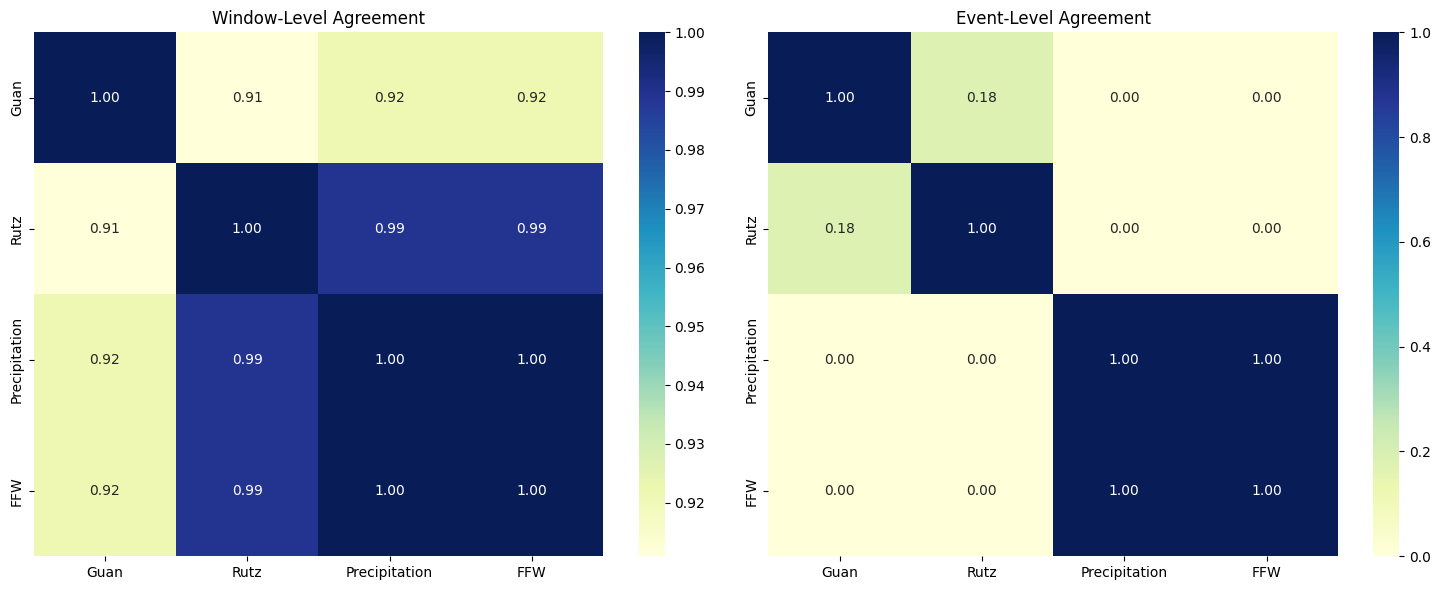

In [4]:
crosstab = pd.crosstab(pdf['Rutz_Label_approx'], pdf['Guan_Label_approx'])
print(crosstab)


Guan_Label_approx       0.0      1.0
Rutz_Label_approx                   
0.0                33708446  2769647
1.0                  523371    11799


In [ ]:

# total_events = len(pdf)
# both_detected = sum((pdf['Guan_Label_approx'] == 1) & (pdf['Rutz_Label_approx'] == 1))
# neither_detected = sum((pdf['Guan_Label_approx'] == 0) & (pdf['Rutz_Label_approx'] == 0))
# only_guan = sum((pdf['Guan_Label_approx'] == 1) & (pdf['Rutz_Label_approx'] == 0))
# only_rutz = sum((pdf['Guan_Label_approx'] == 0) & (pdf['Rutz_Label_approx'] == 1))

# # Print basic statistics
# print("\nBasic Statistics:")
# print(f"Total Timestamps: {total_events}")
# print(f"Events detected by both methods: {both_detected} ({both_detected/total_events*100:.1f}%)")
# print(f"Events detected by neither method: {neither_detected} ({neither_detected/total_events*100:.1f}%)")
# print(f"Events detected only by Guan: {only_guan} ({only_guan/total_events*100:.1f}%)")
# print(f"Events detected only by Rutz: {only_rutz} ({only_rutz/total_events*100:.1f}%)")

# # Confusion matrix and metrics
from scipy.sparse import coo_matrix
pdf1_cleaned = pdf1.dropna(subset=['Precipitation_Label_approx'])

combined_labels = list(zip(
    pdf1_cleaned['Guan_Label_approx'], 
    pdf1_cleaned['Rutz_Label_approx'], 
    pdf1_cleaned['Precipitation_Label_approx'], 
    pdf1_cleaned['ffw']
))
unique_labels, encoded_labels = np.unique(combined_labels, axis=0, return_inverse=True)

cm_sparse = coo_matrix(
    (np.ones_like(encoded_labels), (encoded_labels, encoded_labels)), 
    shape=(len(unique_labels), len(unique_labels))
).toarray()

plt.figure(figsize=(10, 8))
sns.heatmap(cm_sparse, annot=True, fmt='d', xticklabels=["Guan", "Rutz", "Precipitation", "Flashfloods"], 
            yticklabels=["Guan", "Rutz", "Precipitation", "Flashfloods"], cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



KeyboardInterrupt: 

In [5]:
TP = crosstab.loc[1.0, 1.0]
TN = crosstab.loc[0.0, 0.0]
FP = crosstab.loc[0.0, 1.0]
FN = crosstab.loc[1.0, 0.0]

accuracy = (TP + TN) / crosstab.sum().sum()
precision_1 = TP / (TP + FP) if (TP + FP) != 0 else 0
recall_1 = TP / (TP + FN) if (TP + FN) != 0 else 0
f1_score_1 = 2 * (precision_1 * recall_1) / (precision_1 + recall_1) if (precision_1 + recall_1) != 0 else 0
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision for Guan_Label_approx: {precision_1:.4f}")
print(f"Recall for Guan_Label_approx: {recall_1:.4f}")
print(f"F1 Score for Guan_Label_approx: {f1_score_1:.4f}")


Accuracy: 0.9110
Precision for Guan_Label_approx: 0.0042
Recall for Guan_Label_approx: 0.0220
F1 Score for Guan_Label_approx: 0.0071


In [6]:
pdf["Timestamp"] = pd.to_datetime(pdf["Timestamp"])

df_filtered = pdf.dropna(subset=["Rutz_Label_exact"])
df_filtered["Rutz_Label_exact"] = df_filtered["Rutz_Label_exact"].astype(int)

df_filtered["Group"] = (df_filtered["Rutz_Label_exact"] != df_filtered["Rutz_Label_exact"].shift()).cumsum()

group_stats = df_filtered.groupby(["Group", "Rutz_Label_exact"]).agg(
    Start=("Timestamp", "first"),
    End=("Timestamp", "last"),
    Duration=("Timestamp", lambda x: (x.iloc[-1] - x.iloc[0]).total_seconds() / 3600 + 1/60),
).reset_index()

results = group_stats.groupby("Rutz_Label_exact").agg(
    Max_Duration=("Duration", "max"), 
).reset_index()

print("Group Statistics:")
print(group_stats)
print("\nMax Durations:")
print(results)


Group Statistics:
     Group  Rutz_Label_exact               Start                 End  \
0        1                 1 2006-01-01 00:00:00 2006-01-01 00:00:00   
1        2                 0 2006-01-01 03:00:00 2006-01-01 09:00:00   
2        3                 1 2006-01-01 00:00:00 2006-01-01 00:00:00   
3        4                 0 2006-01-01 03:00:00 2006-01-01 09:00:00   
4        5                 1 2006-01-01 00:00:00 2006-01-01 00:00:00   
..     ...               ...                 ...                 ...   
783    784                 0 2006-06-15 12:00:00 2006-06-15 06:00:00   
784    785                 1 2006-06-15 09:00:00 2006-06-15 12:00:00   
785    786                 0 2006-06-15 15:00:00 2006-06-15 06:00:00   
786    787                 1 2006-06-15 09:00:00 2006-06-15 09:00:00   
787    788                 0 2006-06-15 12:00:00 2006-12-31 21:00:00   

        Duration  
0       0.016667  
1       6.016667  
2       0.016667  
3       6.016667  
4       0.016667  
.. 

/tmp/ipykernel_2106/3481467056.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Rutz_Label_exact"] = df_filtered["Rutz_Label_exact"].astype(int)
/tmp/ipykernel_2106/3481467056.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Group"] = (df_filtered["Rutz_Label_exact"] != df_filtered["Rutz_Label_exact"].shift()).cumsum()


In [ ]:


def define_events(df, label_cols, event_duration, threshold_ratio):
    result_df = df.copy()
    result_df['Timestamp'] = pd.to_datetime(result_df['Timestamp'])
    result_df = result_df.sort_values('Timestamp')
    
    event_columns = {}

    for label_col in label_cols:
        new_col_name = f"{label_col}_events"
        result_df[new_col_name] = 0
        
        start_times = pd.date_range(
            start=result_df['Timestamp'].min(),
            end=result_df['Timestamp'].max() - event_duration,
            freq=event_duration
        )
        
        for start_time in start_times:
            end_time = start_time + event_duration
            
            mask = (result_df['Timestamp'] >= start_time) & (result_df['Timestamp'] < end_time)
            window_data = result_df.loc[mask, label_col]
            
            if len(window_data) > 0:
                ones_count = (window_data == 1).sum()
                zeros_count = (window_data == 0).sum()
                
                if zeros_count > 0 and ones_count / zeros_count >= threshold_ratio:
                    result_df.loc[mask, new_col_name] = 1
        
        event_columns[label_col] = new_col_name

    guan_events = result_df[event_columns[label_cols[0]]]
    rutz_events = result_df[event_columns[label_cols[1]]]


    cm = confusion_matrix(guan_events, rutz_events)
    print(f"\nConfusion Matrix for Guan vs. Rutz events:")
    print(cm)

    for label_col in label_cols:
        new_col_name = event_columns[label_col]
        events_count = (result_df[new_col_name] == 1).sum()
        non_events_count = (result_df[new_col_name] == 0).sum()
        print(f"\nSummary for {label_col}:")
        print(f"Number of events (1s): {events_count}")
        print(f"Number of non-events (0s): {non_events_count}")
    
    return result_df

event_duration = timedelta(hours=12)
threshold_ratio = 0.1
label_cols = ["Guan_Label_approx", "Rutz_Label_approx"]
result = define_events(
    df=pdf, 
    label_cols=label_cols,
    event_duration=event_duration,
    threshold_ratio=threshold_ratio
)


In [9]:
result

,Timestamp,Site,Latitude,Longitude,ZWD,Wet Gradient North,Wet Gradient East,IVT,Rutz_Label_exact,IVT_approx,Rutz_Label_approx,Guan_Label_exact,Guan_Label_approx,Precipitation_Label_exact,Precipitation_Label_approx,ffw,Guan_Label_approx_events,Rutz_Label_approx_events
0,2006-01-01 00:00:00,7ODM,34.116407,-117.093192,98.8,-0.83,-1.14,486.503723,1.0,486.503723,1.0,0.0,0.0,0.0,0.0,0,0,0
45076,2006-01-01 00:00:00,OAES,34.141005,-116.067735,79.6,1.78,-1.01,517.344360,1.0,517.344360,1.0,0.0,0.0,0.0,0.0,0,0,0
69688,2006-01-01 00:00:00,RELA,36.715379,-116.554288,50.4,1.24,0.17,244.772141,0.0,244.772141,0.0,0.0,0.0,0.0,0.0,0,0,0
44499,2006-01-01 00:00:00,NOPK,33.979735,-118.348008,103.1,1.30,-0.29,317.165131,1.0,317.165131,1.0,0.0,0.0,0.0,0.0,0,0,0
3757,2006-01-01 00:00:00,BALD,37.783427,-118.901390,-1.9,1.21,-0.05,119.284042,0.0,119.284042,0.0,0.0,0.0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36941550,2006-12-31 23:55:00,LINJ,34.662021,-118.139198,38.0,-0.19,-0.31,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN,0,0,0
37003470,2006-12-31 23:55:00,THCP,35.158182,-118.414570,28.8,-0.74,0.12,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN,0,0,0
36941262,2006-12-31 23:55:00,LINC,37.637193,-119.017285,14.8,0.02,0.13,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN,0,0,0
36944142,2006-12-31 23:55:00,LVMS,34.733605,-119.103683,27.8,0.07,-0.26,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN,0,0,0
